# Problem 4 - Bootstrap Confidence Intervals and Permutation Tests

This notebook implements a percentile bootstrap confidence interval and a two-group permutation
test, then demonstrates both methods on simulated data.


In [1]:
### IMPORTS
# Core numerical and dataframe libraries.
import pandas as pd
import numpy as np

# Plotting tools for simulation distributions.
import matplotlib.pyplot as plt
plt.style.use('default')

# Linear regression is used for the bootstrap slope demonstration.
from sklearn.linear_model import LinearRegression


In [2]:
### GLOBAL VARS
# Fixed seed keeps bootstrap and permutation demonstrations reproducible.
RANDOM_SEED = 123


## Part A - Bootstrap Confidence Interval

The bootstrap approximates the sampling distribution of a statistic by resampling observations with
replacement from the observed data.


In [3]:
def _resample_data(data, indices):
    """Return rows or elements of data selected by bootstrap indices."""

    if isinstance(data, pd.DataFrame):
        # DataFrame input is useful for row-resampling regression examples.
        return data.iloc[indices].reset_index(drop=True)

    # Array-like input is enough for one-sample statistics such as a mean or median.
    return np.asarray(data)[indices]


def bootstrap_ci(data, statistic_function, n_boot=2000, confidence=0.95, random_state=RANDOM_SEED):
    """Compute a percentile bootstrap confidence interval for a statistic."""

    rng = np.random.default_rng(random_state)
    n = len(data)

    # Compute the statistic on the original observed sample.
    point_estimate = statistic_function(data)

    # Recompute the statistic on many bootstrap samples of size n drawn with replacement.
    boot_stats = np.empty(n_boot)
    for b in range(n_boot):
        sample_idx = rng.integers(0, n, size=n)
        boot_sample = _resample_data(data, sample_idx)
        boot_stats[b] = statistic_function(boot_sample)

    # Percentile endpoints come from the empirical bootstrap distribution.
    alpha = 1.0 - confidence
    lower = np.quantile(boot_stats, alpha / 2.0)
    upper = np.quantile(boot_stats, 1.0 - alpha / 2.0)

    return {
        "point_estimate": point_estimate,
        "lower": lower,
        "upper": upper,
        "confidence": confidence,
        "bootstrap_statistics": boot_stats,
    }


def plot_bootstrap_distribution(bootstrap_result, title="Bootstrap distribution"):
    """Plot bootstrap statistics and mark the percentile confidence interval."""

    boot_stats = bootstrap_result["bootstrap_statistics"]
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    ax.hist(boot_stats, bins=35, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(bootstrap_result["point_estimate"], color="black", linewidth=2, label="point estimate")
    ax.axvline(bootstrap_result["lower"], color="red", linestyle="--", linewidth=2, label="CI endpoints")
    ax.axvline(bootstrap_result["upper"], color="red", linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("bootstrap statistic")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
    plt.show()


In [4]:
# Simulate a simple regression data set for a bootstrap CI for the slope.
rng = np.random.default_rng(RANDOM_SEED)
x = rng.uniform(0.0, 5.0, size=100)
y = 1.0 + 2.0 * x + rng.normal(scale=1.0, size=100)
regression_data = pd.DataFrame({"x": x, "y": y})


def slope_statistic(sample):
    """Fit simple linear regression and return the slope coefficient."""

    model = LinearRegression()
    model.fit(sample[["x"]], sample["y"])
    return float(model.coef_[0])

# Compute and display the percentile bootstrap confidence interval.
slope_ci = bootstrap_ci(regression_data, slope_statistic, n_boot=2000, confidence=0.95)

bootstrap_summary = pd.DataFrame({
    "point_estimate": [slope_ci["point_estimate"]],
    "lower": [slope_ci["lower"]],
    "upper": [slope_ci["upper"]],
    "confidence": [slope_ci["confidence"]],
})

bootstrap_summary


,point_estimate,lower,upper,confidence
0,1.931819,1.797632,2.064455,0.95


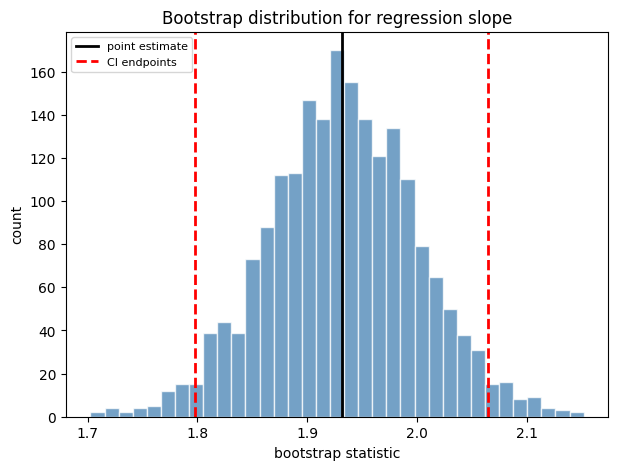

In [5]:
# Plot the bootstrap distribution of slope estimates.
plot_bootstrap_distribution(slope_ci, title="Bootstrap distribution for regression slope")


## Part B - Permutation Test

A permutation test approximates the null distribution by repeatedly shuffling group labels. Under
the null hypothesis of no group effect, group labels are exchangeable.


In [6]:
def permutation_test_two_groups(group1, group2, statistic_function, n_perm=5000, alternative="two-sided", random_state=RANDOM_SEED):
    """Run a permutation test comparing two groups with a user-supplied statistic."""

    rng = np.random.default_rng(random_state)
    group1 = np.asarray(group1)
    group2 = np.asarray(group2)
    n1 = len(group1)

    # The observed statistic uses the original group labels.
    observed_stat = statistic_function(group1, group2)

    # Pool observations because labels are exchangeable under the null hypothesis.
    pooled = np.concatenate([group1, group2])
    perm_stats = np.empty(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_group1 = shuffled[:n1]
        perm_group2 = shuffled[n1:]
        perm_stats[i] = statistic_function(perm_group1, perm_group2)

    # Compute the p-value according to the requested alternative.
    if alternative == "two-sided":
        extreme = np.abs(perm_stats) >= abs(observed_stat)
    elif alternative == "greater":
        extreme = perm_stats >= observed_stat
    elif alternative == "less":
        extreme = perm_stats <= observed_stat
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    # Add-one smoothing avoids returning p=0 from a finite simulation.
    p_value = (np.sum(extreme) + 1) / (n_perm + 1)

    return {
        "observed_statistic": observed_stat,
        "p_value": p_value,
        "alternative": alternative,
        "permutation_statistics": perm_stats,
    }


def plot_permutation_distribution(permutation_result, title="Permutation null distribution"):
    """Plot permutation statistics and mark the observed statistic."""

    perm_stats = permutation_result["permutation_statistics"]
    observed = permutation_result["observed_statistic"]

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    ax.hist(perm_stats, bins=40, color="gray", alpha=0.75, edgecolor="white")
    ax.axvline(observed, color="red", linewidth=2.5, label="observed statistic")
    ax.axvline(-observed, color="red", linestyle="--", linewidth=1.5, label="opposite tail")
    ax.set_title(title)
    ax.set_xlabel("permuted statistic")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
    plt.show()


In [7]:
# Simulate two groups with a modest mean difference.
rng = np.random.default_rng(RANDOM_SEED)
group1 = rng.normal(loc=0.0, scale=1.0, size=45)
group2 = rng.normal(loc=0.55, scale=1.0, size=50)


def difference_in_means(a, b):
    """Return group 2 mean minus group 1 mean."""

    return float(np.mean(b) - np.mean(a))

# Run the permutation test for a two-sided alternative.
perm_result = permutation_test_two_groups(
    group1,
    group2,
    statistic_function=difference_in_means,
    n_perm=5000,
    alternative="two-sided",
)

permutation_summary = pd.DataFrame({
    "observed_statistic": [perm_result["observed_statistic"]],
    "p_value": [perm_result["p_value"]],
    "alternative": [perm_result["alternative"]],
})

permutation_summary


,observed_statistic,p_value,alternative
0,0.425514,0.027195,two-sided


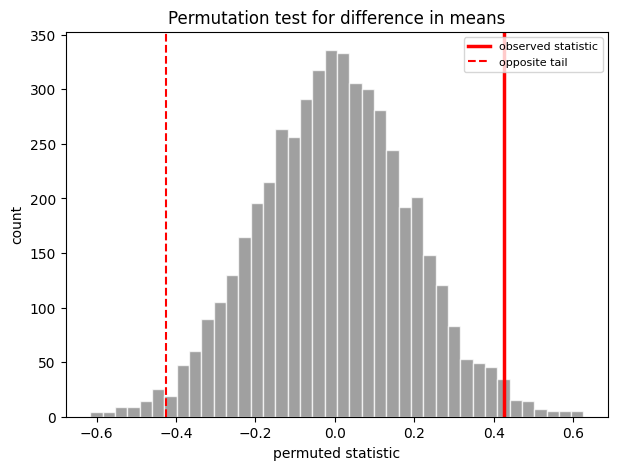

In [8]:
# Plot the null distribution generated by permuting group labels.
plot_permutation_distribution(perm_result, title="Permutation test for difference in means")


## Interpretation

Bootstrap resampling samples observations with replacement from the observed data to approximate
the sampling distribution of a statistic and build a confidence interval. Permutation testing shuffles
group labels to approximate the null distribution of a test statistic under no group effect.
Exchangeability means that, under the null hypothesis, the labels could have been assigned to the
observations in any order without changing the joint distribution. A permutation test is appropriate
when this exchangeability assumption is credible, such as randomized group assignment or otherwise
comparable groups under the null.
